In [1]:
!nvidia-smi
%matplotlib inline

Sun Apr 12 16:50:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100                    On  |   00000000:A6:00.0 Off |                    0 |
| N/A   33C    P0             67W /  700W |       0MiB /  95830MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
from helper_functions_testing import (
    batch_generate_responses_qwen3,
    get_judgments_from_responses,
    run_experiment,
    retrieve_results,
    prepare_test_prompts,
    obtain_results_without)
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
import pandas as pd
import json
import re
import numpy as np
from typing import List, Optional, Dict, Any
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from tqdm import tqdm
import torch

In [6]:
import os
print("HF_HOME:", os.environ.get("HF_HOME"))
print("HF_DATASETS_CACHE:", os.environ.get("HF_DATASETS_CACHE"))
print("HF_HUB_CACHE:", os.environ.get("HF_HUB_CACHE"))
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"

# 可选：确保没被错误地关掉进度条
os.environ.pop("HF_HUB_DISABLE_PROGRESS_BARS", None)

HF_HOME: /scratch-local/yhuang/huggingface_cache
HF_DATASETS_CACHE: /scratch-local/yhuang/huggingface_cache/datasets
HF_HUB_CACHE: /scratch-local/yhuang/huggingface_cache/hub


### Loading verified examples (UNDER_gold)

In [4]:
verified_examples = "../Data/UNDER_gold.csv"
df_verified_examples = pd.read_csv(verified_examples)

### General launching commands and code

In [ ]:
# Using sglang to run the larger model

DSR1_1_5B = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
DSR1_7B = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
DSR1_14B = "deepseek-ai/DeepSeek-R1-Distill-Qwen-14B"
DSR1_32B = "deepseek-ai/DeepSeek-R1-Distill-Qwen-32B"

"""
module load 2023
module load CUDA/12.4.0
source ~/sglang-venv-2/bin/activate
huggingface-cli login



# 创建所有必要的目录
mkdir -p /scratch-local/yhuang/sglang_cache
mkdir -p /scratch-local/yhuang/huggingface_cache
mkdir -p /scratch-local/yhuang/torch_cache
mkdir -p /scratch-local/yhuang/cuda_cache
mkdir -p /scratch-local/yhuang/xdg_cache
mkdir -p /scratch-local/yhuang/tmp
mkdir -p /scratch-local/yhuang/logs

# 设置所有相关环境变量
export SGLANG_CACHE_DIR=/scratch-local/yhuang/sglang_cache
export TRANSFORMERS_CACHE=/scratch-local/yhuang/huggingface_cache
export HF_HOME=/scratch-local/yhuang/huggingface_cache
export HF_DATASETS_CACHE=/scratch-local/yhuang/huggingface_cache/datasets
export TORCH_HOME=/scratch-local/yhuang/torch_cache
export CUDA_CACHE_PATH=/scratch-local/yhuang/cuda_cache
export XDG_CACHE_HOME=/scratch-local/yhuang/xdg_cache
export TMPDIR=/scratch-local/yhuang/tmp
export TEMP=/scratch-local/yhuang/tmp
export TMP=/scratch-local/yhuang/tmp
export SGLANG_LOG_DIR=/scratch-local/yhuang/logs

# launching
python -m sglang.launch_server --port 7501 --model-path deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B --trust-remote-code
python -m sglang.launch_server --port 7501 --model-path deepseek-ai/DeepSeek-R1-Distill-Qwen-7B --trust-remote-code
python -m sglang.launch_server --port 7501 --model-path deepseek-ai/DeepSeek-R1-Distill-Qwen-14B --trust-remote-code
CUDA_VISIBLE_DEVICES=0,1 python -m sglang.launch_server --port 7501 --model-path deepseek-ai/DeepSeek-R1-Distill-Qwen-32B --trust-remote-code --tp 2
"""

In [5]:
system_prompt = """
You are an expert analyst. Your task is to analyze and determine whether an input user query is "fully specified" or "underspecified".

"""

task_FS_UND = """
Analyze the following input user query:

{"query": "TARGET"}

Please provide your analysis in the following JSON format:

{"query": "TARGET", "reasoning": "[YOUR_DETAILED_REASONING]", "judgment": "[fully specified/underspecified]"}
"""

In [6]:
import openai
import re
client = openai.Client(
    base_url="http://localhost:7501/v1", api_key="EMPTY")


def batch_generate_responses_openai(prompts, system_prompt=system_prompt,
                             temperature=0.7, max_new_tokens=32768, batch_size=5):
    responses = []
    thoughts = []

    for i in tqdm(range(0, len(prompts), batch_size)):
        batch_prompts = prompts[i:i+batch_size]
        batch_responses = []
        batch_thoughts = []

        for prompt in batch_prompts:
            try:
                response = client.chat.completions.create(
                    model="default",
                    messages=[
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": prompt},
                    ],
                    temperature=temperature,
                    max_tokens=max_new_tokens,
                )

                full_text = response.choices[0].message.content

                try:
                    # 查找结束标签位置
                    end_think_pos = full_text.find('</think>')

                    if end_think_pos != -1:
                        # 思考部分是从开始到</think>标签
                        thought = full_text[:end_think_pos].strip()
                        # 回答部分是</think>标签之后的内容
                        answer = full_text[end_think_pos + len('</think>'):].strip()
                    else:
                        # 没有找到思考标签，将整个回复视为答案
                        thought = ""
                        answer = full_text
                except Exception as parsing_error:
                    print(f"解析思考过程时出错: {parsing_error}")
                    thought = ""
                    answer = full_text  # 回退到完整回复

                batch_responses.append(answer)
                batch_thoughts.append(thought)

            except Exception as e:
                print(f"API调用时出错: {e}")
                batch_responses.append(None)
                batch_thoughts.append(None)

        responses.extend(batch_responses)
        thoughts.extend(batch_thoughts)

    return responses, thoughts

def run_experiment_openai(input_prompts, test_df):
  output = batch_generate_responses_openai(input_prompts)
  df = test_df.copy()
  df['thinking'] = output[1]
  df['model_response'] = output[0]
  to_process = output[0]
  processed_judgments = get_judgments_from_responses(to_process)
  df['model_pred'] = processed_judgments

  return df

#### DeepSeek 1.5B

In [7]:
test_prompts = prepare_test_prompts(df_verified_examples, task_FS_UND)
print(test_prompts[0])

Start preparing prompts...
# Testing data points: 150
Generation complete: 150 prompts
Average prompt length: 331 bytes (~82 tokens)

Analyze the following input user query:

{"query": "When was the first world war broke out?"}

Please provide your analysis in the following JSON format:

{"query": "When was the first world war broke out?", "reasoning": "[YOUR_DETAILED_REASONING]", "judgment": "[fully specified/underspecified]"}



In [8]:
test_df = run_experiment_openai(test_prompts, df_verified_examples)
test_df

100%|██████████| 30/30 [08:04<00:00, 16.16s/it]

Respond content: Alright, let's tackle this user query. The user is asking, "Who sings the song i will try to fix you?" Hmm, I need to figure out if this query is fully specified or underspecified. 

First, I'll look ...
Respond content: ```json
{"query": "Moss is an example of which type of plant?", "reasoning": "The query is underspecified because it lacks sufficient information to determine the exact type of plant. The word 'moss' ...
Respond content: {"query": "Where does the movie 10 things i hate about you take place?", "reasoning": "The user query asks for the location of the movie titled '10 things i hate about you.' However, the query does no...
Respond content: The user query "Help me create a monthly budget plan to save for a new car." is underspecified. The lack of specific financial details such as income, savings goals, and car models leaves the user wit...
Respond content: ```json
{"query": "How do I take professional-looking photos with my smartphone?", "reasoning": "Th

,Unnamed: 0,request,gold_judgment,direct_source,category,reasoning,original_annotation,thinking,model_response,model_pred
0,1118,When was the first world war broke out?,underspecified,AmbigNQ,Undetermined perspective or granularity,The phrase “broke out” can be interpreted from...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Alright, so I need to figure out if the user q...","{""query"": ""When was the first world war broke ...",fully specified
1,5585,Who sings the song i will try to fix you?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question allows multiple granularities: it...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...",,"Alright, let's tackle this user query. The use...",error
2,9330,Who is the head of the nation in india?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question can refer to the role or title of...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Alright, so I've got this user query: ""Who is ...","```json\n{\n ""query"": ""Who is the head of the...",underspecified
3,9602,Moss is an example of which type of plant?,underspecified,AmbigNQ,Undetermined perspective or granularity,The term “type” can refer to different taxonom...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Okay, I'm trying to figure out whether the use...","```json\n{""query"": ""Moss is an example of whic...",error
4,4145,How long can you serve in the house?,underspecified,AmbigNQ,"Undetermined lexicons or references, Undetermi...",The term “house” is referentially ambiguous be...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Okay, so I'm trying to figure out if this user...","```json\n{\n ""query"": ""How long can you serve...",underspecified
...,...,...,...,...,...,...,...,...,...,...
145,1213,Give me a bulleted list of the 5 highest mount...,fully specified,CLAMBER,fully specified,This question is fully specified because it re...,NaN,"Okay, I need to determine if the user's query ...","```json\n{\n ""query"": ""Give me a bulleted lis...",fully specified
146,2274,Who is the author of the novel Taipei by Tao Lin?,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"Okay, so I'm trying to figure out if the user ...","```json\n{\n ""query"": ""Who is the author of t...",fully specified
147,356,What's the average body length of Brania russe...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"Okay, I need to determine if the given user qu...","```json\n{\n ""query"": ""What's the average bod...",underspecified
148,294,Is Bolusia capensis a unicellular organism in ...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"Okay, so I'm looking at this user query and tr...","{""query"": ""Is Bolusia capensis a unicellular o...",underspecified


In [9]:
retrieve_results(test_df, "DS_1.5B_verified_test")

There are unrecognized labels.


No error found, directly process the data.
                 precision    recall  f1-score   support

fully specified       0.50      0.27      0.35        51
 underspecified       0.70      0.86      0.77        99

       accuracy                           0.66       150
      macro avg       0.60      0.57      0.56       150
   weighted avg       0.63      0.66      0.63       150



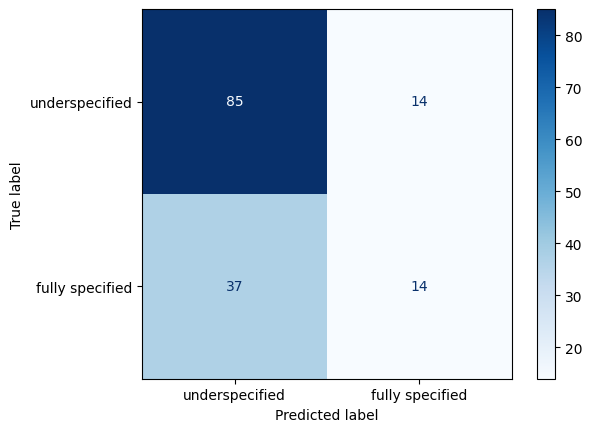

In [6]:
test_df = pd.read_csv("DS_1.5B_verified_test_corrected.csv")
retrieve_results(test_df, "DS_1.5B_verified_test_corrected")

#### DeepSeek 7B

In [14]:
test_prompts = prepare_test_prompts(df_verified_examples, task_FS_UND)
print(test_prompts[0])

Start preparing prompts...
# Testing data points: 150
Generation complete: 150 prompts
Average prompt length: 331 bytes (~82 tokens)

Analyze the following input user query:

{"query": "When was the first world war broke out?"}

Please provide your analysis in the following JSON format:

{"query": "When was the first world war broke out?", "reasoning": "[YOUR_DETAILED_REASONING]", "judgment": "[fully specified/underspecified]"}



In [15]:
test_df = run_experiment_openai(test_prompts, df_verified_examples)
test_df

100%|██████████| 30/30 [15:37<00:00, 31.24s/it]


,Unnamed: 0,request,gold_judgment,direct_source,category,reasoning,original_annotation,thinking,model_response,model_pred
0,1118,When was the first world war broke out?,underspecified,AmbigNQ,Undetermined perspective or granularity,The phrase “broke out” can be interpreted from...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Okay, so I need to figure out whether the user...","```json\n{\n ""query"": ""When was the first wor...",fully specified
1,5585,Who sings the song i will try to fix you?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question allows multiple granularities: it...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Alright, I need to analyze whether the query ""...","{""query"": ""Who sings the song i will try to fi...",underspecified
2,9330,Who is the head of the nation in india?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question can refer to the role or title of...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Okay, so I need to figure out whether the user...","```json\n{\n ""query"": ""Who is the head of the...",underspecified
3,9602,Moss is an example of which type of plant?,underspecified,AmbigNQ,Undetermined perspective or granularity,The term “type” can refer to different taxonom...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Okay, I need to analyze the user query: ""Moss ...","```json\n{\n ""query"": ""Moss is an example of ...",fully specified
4,4145,How long can you serve in the house?,underspecified,AmbigNQ,"Undetermined lexicons or references, Undetermi...",The term “house” is referentially ambiguous be...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Okay, so I have to determine if the user query...","```json\n{\n ""query"": ""How long can you serve...",underspecified
...,...,...,...,...,...,...,...,...,...,...
145,1213,Give me a bulleted list of the 5 highest mount...,fully specified,CLAMBER,fully specified,This question is fully specified because it re...,NaN,"Alright, so I need to determine if the given q...","```json\n{\n ""query"": ""Give me a bulleted lis...",fully specified
146,2274,Who is the author of the novel Taipei by Tao Lin?,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"Okay, I need to figure out if the user's query...","{""query"": ""Who is the author of the novel Taip...",fully specified
147,356,What's the average body length of Brania russe...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"Okay, so I need to figure out whether the quer...","{""query"": ""What's the average body length of B...",fully specified
148,294,Is Bolusia capensis a unicellular organism in ...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"Alright, so I need to determine whether the us...","```json\n{\n ""query"": ""Is Bolusia capensis a ...",underspecified


No error found, directly process the data.
                 precision    recall  f1-score   support

fully specified       0.59      0.76      0.67        51
 underspecified       0.86      0.73      0.79        99

       accuracy                           0.74       150
      macro avg       0.72      0.75      0.73       150
   weighted avg       0.77      0.74      0.75       150



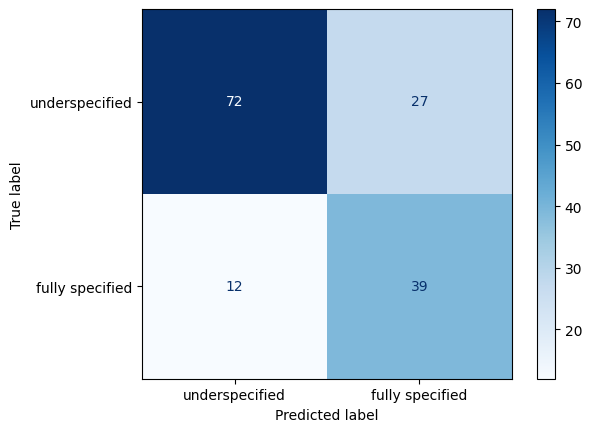

In [16]:
retrieve_results(test_df, "DS_7B_verified_test")

#### DeepSeek 14B

In [9]:
test_prompts = prepare_test_prompts(df_verified_examples, task_FS_UND)
print(test_prompts[0])

Start preparing prompts...
# Testing data points: 150
Generation complete: 150 prompts
Average prompt length: 331 bytes (~82 tokens)

Analyze the following input user query:

{"query": "When was the first world war broke out?"}

Please provide your analysis in the following JSON format:

{"query": "When was the first world war broke out?", "reasoning": "[YOUR_DETAILED_REASONING]", "judgment": "[fully specified/underspecified]"}



In [10]:
test_df = run_experiment_openai(test_prompts, df_verified_examples)
test_df

100%|██████████| 30/30 [28:17<00:00, 56.59s/it]

Respond content: The query "How can I save money on my monthly expenses?" is **underspecified** because it lacks essential details such as the user's income, expenses, lifestyle, financial goals, specific areas of int...


,Unnamed: 0,request,gold_judgment,direct_source,category,reasoning,original_annotation,thinking,model_response,model_pred
0,1118,When was the first world war broke out?,underspecified,AmbigNQ,Undetermined perspective or granularity,The phrase “broke out” can be interpreted from...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Okay, so I need to determine if the query ""Whe...","```json\n{\n ""query"": ""When was the first wor...",fully specified
1,5585,Who sings the song i will try to fix you?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question allows multiple granularities: it...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Okay, so I need to figure out whether the quer...","{""query"": ""Who sings the song i will try to fi...",fully specified
2,9330,Who is the head of the nation in india?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question can refer to the role or title of...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Okay, I need to figure out if the query ""Who i...","The query ""Who is the head of the nation in in...",underspecified
3,9602,Moss is an example of which type of plant?,underspecified,AmbigNQ,Undetermined perspective or granularity,The term “type” can refer to different taxonom...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Okay, so I need to determine whether the user ...","```json\n{\n ""query"": ""Moss is an example of ...",fully specified
4,4145,How long can you serve in the house?,underspecified,AmbigNQ,"Undetermined lexicons or references, Undetermi...",The term “house” is referentially ambiguous be...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Alright, so I've got this query: ""How long can...","```json\n{\n ""query"": ""How long can you serve...",underspecified
...,...,...,...,...,...,...,...,...,...,...
145,1213,Give me a bulleted list of the 5 highest mount...,fully specified,CLAMBER,fully specified,This question is fully specified because it re...,NaN,"Okay, so I have to figure out whether the user...","```json\n{\n ""query"": ""Give me a bulleted lis...",fully specified
146,2274,Who is the author of the novel Taipei by Tao Lin?,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"Okay, so I need to determine whether the query...","```json\n{\n ""query"": ""Who is the author of t...",underspecified
147,356,What's the average body length of Brania russe...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"Okay, so I need to figure out if the query ""Wh...","```json\n{\n ""query"": ""What's the average bod...",underspecified
148,294,Is Bolusia capensis a unicellular organism in ...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"Okay, so I have this query: ""Is Bolusia capens...","{\n ""query"": ""Is Bolusia capensis a unicellul...",underspecified


In [11]:
retrieve_results(test_df, "DS_14B_verified_test")

There are unrecognized labels.


No error found, directly process the data.
                 precision    recall  f1-score   support

fully specified       0.52      0.63      0.57        51
 underspecified       0.79      0.71      0.74        99

       accuracy                           0.68       150
      macro avg       0.66      0.67      0.66       150
   weighted avg       0.70      0.68      0.69       150



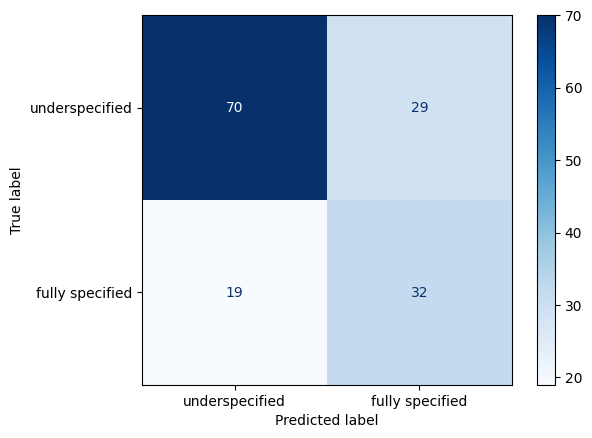

In [7]:
test_df = pd.read_csv("DS_14B_verified_test_corrected.csv")
retrieve_results(test_df, "DS_14B_verified_test_corrected")

#### DeepSeek 32B

In [8]:
test_prompts = prepare_test_prompts(df_verified_examples, task_FS_UND)
print(test_prompts[0])

Start preparing prompts...
# Testing data points: 150
Generation complete: 150 prompts
Average prompt length: 331 bytes (~82 tokens)

Analyze the following input user query:

{"query": "When was the first world war broke out?"}

Please provide your analysis in the following JSON format:

{"query": "When was the first world war broke out?", "reasoning": "[YOUR_DETAILED_REASONING]", "judgment": "[fully specified/underspecified]"}



In [9]:
test_df = run_experiment_openai(test_prompts, df_verified_examples)
test_df

100%|██████████| 30/30 [21:48<00:00, 43.62s/it]

Respond content: The query "Recommend the best smartwatches available in 2023" is **underspecified**. While it clearly states the request, it lacks specific criteria such as price range, features, brand preferences, o...
Respond content: The query "What is the latitude range of Defselrea's habitat?" is underspecified. 

**Reasoning:**
1. **Ambiguity of Defselrea:** The term "Defselrea" is not recognized as a known species, making it u...
Respond content: The query "The right to minimum wage is an example of?" is underspecified. 

**Reasoning:** The question is open-ended and lacks specific context or categories, making it difficult to provide a precis...


,Unnamed: 0,request,gold_judgment,direct_source,category,reasoning,original_annotation,thinking,model_response,model_pred
0,1118,When was the first world war broke out?,underspecified,AmbigNQ,Undetermined perspective or granularity,The phrase “broke out” can be interpreted from...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Okay, so I need to figure out whether the quer...","```json\n{\n ""query"": ""When was the first wor...",fully specified
1,5585,Who sings the song i will try to fix you?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question allows multiple granularities: it...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Okay, I need to analyze whether the query ""Who...","```json\n{\n ""query"": ""Who sings the song i w...",underspecified
2,9330,Who is the head of the nation in india?,underspecified,AmbigNQ,Undetermined perspective or granularity,The question can refer to the role or title of...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Alright, I need to determine whether the query...","{""query"": ""Who is the head of the nation in in...",underspecified
3,9602,Moss is an example of which type of plant?,underspecified,AmbigNQ,Undetermined perspective or granularity,The term “type” can refer to different taxonom...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Okay, I'm looking at the query: ""Moss is an ex...",The query is fully specified because it clearl...,fully specified
4,4145,How long can you serve in the house?,underspecified,AmbigNQ,"Undetermined lexicons or references, Undetermi...",The term “house” is referentially ambiguous be...,"{""annotations"": [{""type"": ""multipleQAs"", ""qaPa...","Okay, so I need to figure out if the query ""Ho...","The query ""How long can you serve in the house...",underspecified
...,...,...,...,...,...,...,...,...,...,...
145,1213,Give me a bulleted list of the 5 highest mount...,fully specified,CLAMBER,fully specified,This question is fully specified because it re...,NaN,"Okay, so I'm trying to figure out whether this...","```json\n{\n ""query"": ""Give me a bulleted lis...",fully specified
146,2274,Who is the author of the novel Taipei by Tao Lin?,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"Okay, so I need to determine whether the query...","```json\n{\n ""query"": ""Who is the author of t...",underspecified
147,356,What's the average body length of Brania russe...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"Alright, I need to analyze whether the user's ...","```json\n{\n ""query"": ""What's the average bod...",underspecified
148,294,Is Bolusia capensis a unicellular organism in ...,fully specified,CLAMBER,fully specified,This question is fully specified because it as...,NaN,"Alright, so I'm trying to figure out whether t...","```json\n{\n ""query"": ""Is Bolusia capensis a ...",fully specified


In [10]:
retrieve_results(test_df, "DS_32B_verified_test")

There are unrecognized labels.


No error found, directly process the data.
                 precision    recall  f1-score   support

fully specified       0.62      0.57      0.59        51
 underspecified       0.79      0.82      0.80        99

       accuracy                           0.73       150
      macro avg       0.70      0.69      0.70       150
   weighted avg       0.73      0.73      0.73       150



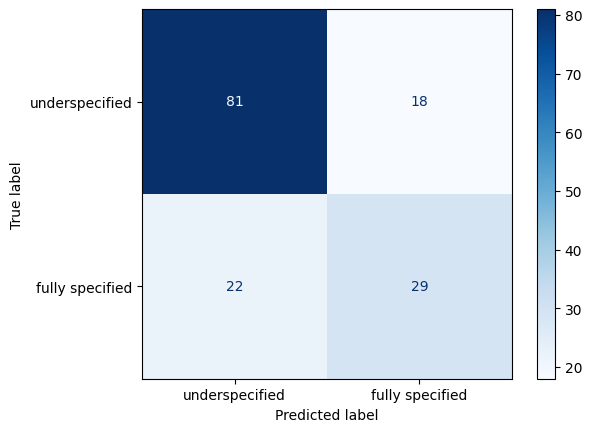

In [12]:
test_df = pd.read_csv("DS_32B_verified_test_corrected.csv")
retrieve_results(test_df, "DS_32B_verified_test_corrected")